# Data Visulization

Now we are gonna visualize our cleaned data.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/cleaned_telco_customer_churn.csv")
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1


In [15]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

---

## Churn Distribution

Pie chart showing how many customers churned and how many didn't.

In [13]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

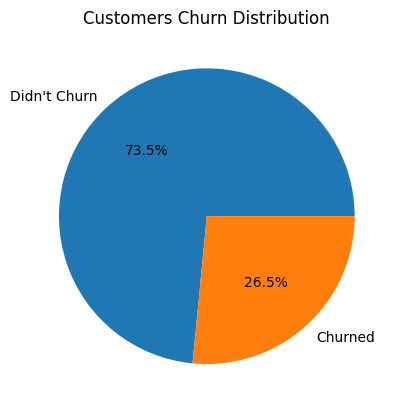

In [14]:
plt.pie(df["Churn"].value_counts(),
        labels=["Didn't Churn", "Churned"],
        autopct="%1.1f%%")
plt.title("Customers Churn Distribution")
plt.show()

- Majority, 73.5%, of the people didn't Churn. 
- While 26.5% of the people Churned.

---

## Churn by Contract Type

Bar chart showing churned customers rate per contract type.

In [34]:
df.groupby("Contract")["Churn"].mean() * 100

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

The mean is showing only the people who Churned as they are being presented by 1, and those who didn't churn are being presented by 0.

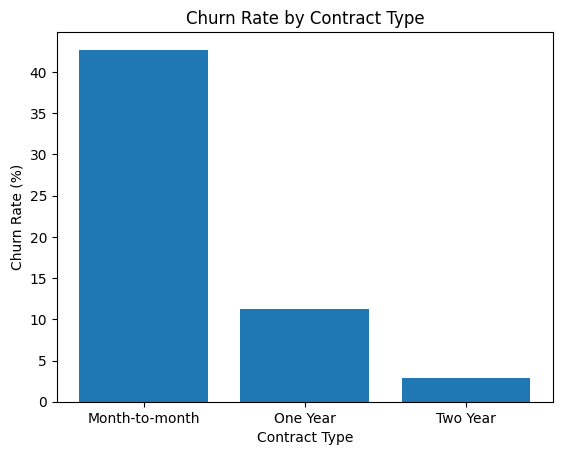

In [35]:
churn_by_contract = df.groupby("Contract")["Churn"].mean() * 100

plt.bar(churn_by_contract.index, churn_by_contract.values)
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Contract Type")
plt.xticks([0, 1, 2], ["Month-to-month", "One Year", "Two Year"])
plt.show()

- The customers who have the Month-to-month contract are the ones churning the most, followed by 1 and then 2 year contract.
- We can say that this has non-linear relationship. As Churning is decreasing with increase in contract period.

---

## Churn by Internet Service

Bar chart showing churn rate per internet service type.

In [36]:
df.groupby("InternetService")["Churn"].mean()*100

InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn, dtype: float64

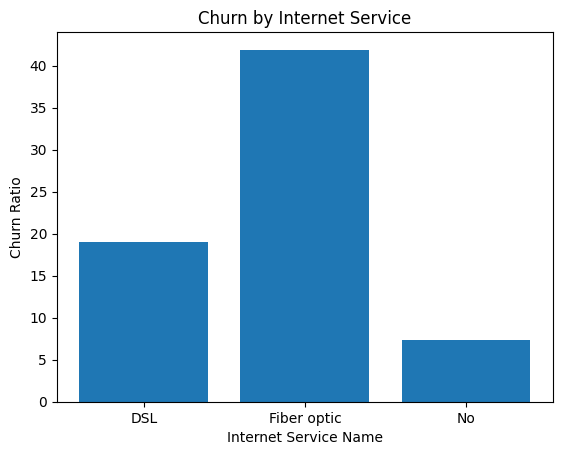

In [ ]:
churn_by_internet = df.groupby("InternetService")["Churn"].mean()*100

plt.bar(churn_by_internet.index, churn_by_internet.values)
plt.xlabel("Internet Service Name")
plt.ylabel("Churn Ratio")
plt.title("Churn by Internet Service")
plt.show()

Okay so people using Fiber optics are tend to churn more. Altough Fiber Optics is pretty better than DSL, this could be because of the price and availability.

---

## Tenure vs Churn

Histogram showing Tenure vs Churn.

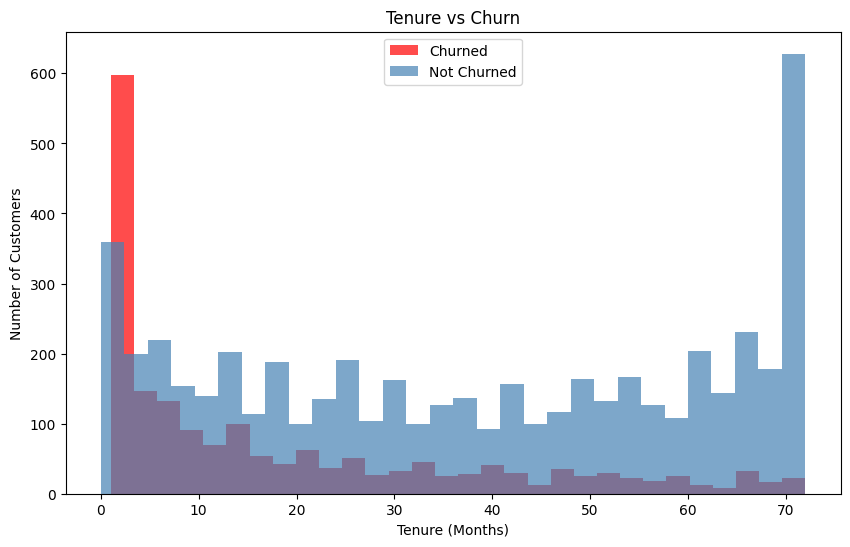

In [56]:
plt.figure(figsize=(10, 6))
plt.hist(df[df["Churn"] == 1]["tenure"], bins=30, alpha=0.7, color="red", label="Churned")
plt.hist(df[df["Churn"] == 0]["tenure"], bins=30, alpha=0.7, color="steelblue", label="Not Churned")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.title("Tenure vs Churn")
plt.legend()
plt.show()

Newer customers churn the most, suggesting that the initial experience with the company is critical. Customers who stay more than 12 months are less likely to leave.

---

## Churn by Citizen Type

Bar chart showing if senior citizens churn more or not.

In [59]:
df.groupby("SeniorCitizen")["Churn"].value_counts()

SeniorCitizen  Churn
0              0        4508
               1        1393
1              0         666
               1         476
Name: count, dtype: int64

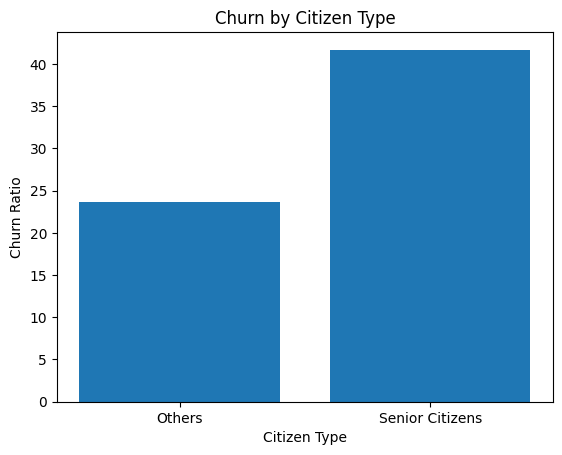

In [64]:
senior_citizens_churn = df.groupby("SeniorCitizen")["Churn"].mean() * 100

plt.bar(senior_citizens_churn.index, senior_citizens_churn.values)
plt.xlabel("Citizen Type")
plt.ylabel("Churn Ratio")
plt.title("Churn by Citizen Type")
plt.xticks([0, 1], ["Others", "Senior Citizens"])
plt.show()

It's clearly visible that the senior citizens tend to Churn more.

---

## Churn by Gender

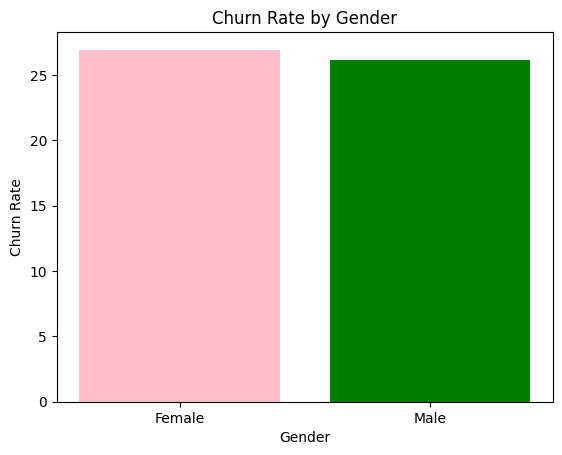

In [73]:
churn_by_gender = df.groupby("gender")["Churn"].mean() * 100

plt.bar(churn_by_gender.index, churn_by_gender.values,  color=["pink", "green"])
plt.xlabel("Gender")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Gender")
plt.xticks([0, 1], ["Female", "Male"])
plt.show()

This shows that the gender has almost no effect on the customers Churn.

---

## Correlation Heatmap

Heatmap of all numerical features vs Churn.

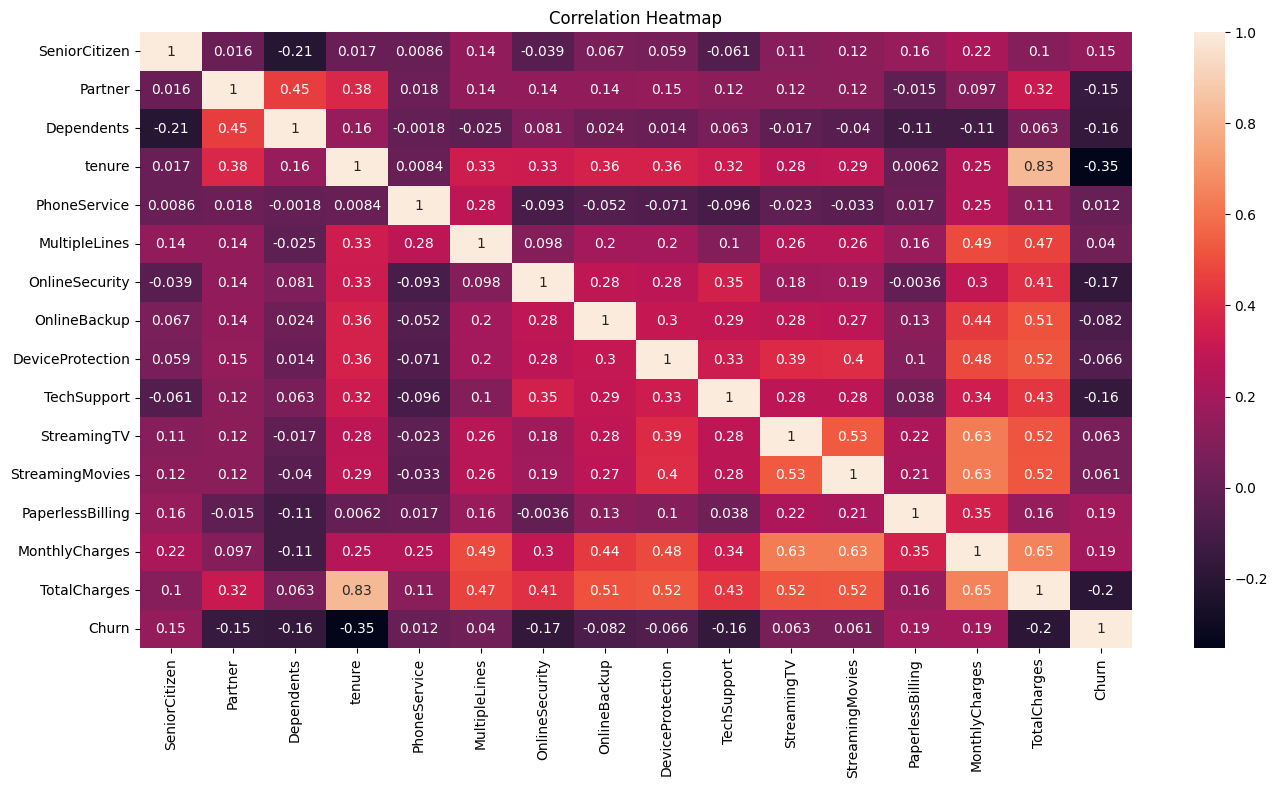

In [ ]:
import seaborn as sn 

plt.figure(figsize = (16,8))
sn.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
# plt.tight_layout()
plt.show()

- Tenure has strong relationship with TotalCharges. The longer the customer stays with the company, the higher the TotalCharges.
- Internet related services have somewhat of a moderate corr with TotalCharges.
- Tenure has a negative corr with Churn. The longer the tenure, the less the churn.

---